<a href="https://colab.research.google.com/github/mohamedekramy19/mohamedekramy19/blob/main/brain_tumour_detection_using_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports Libraries and Tools

In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16  # ✅ مهم جداً!
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ All libraries imported successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All libraries imported successfully!


# Load Datasets

In [ ]:
from sklearn.model_selection import train_test_split

# المسار الرئيسي اللي فيه الـ 4 فولدرات
base_dir = '/content/drive/MyDrive/MRI NEW/'  # عدّلي المسار حسب مكانك

# القوائم اللي هنحفظ فيها المسارات والتصنيفات
all_paths = []
all_labels = []

# الفولدرات الأربعة
folders = ['pituitary', 'glioma', 'meningioma', 'notumor']

# جمع كل الصور من الـ 4 فولدرات
for label in folders:
    folder_path = os.path.join(base_dir, label)
    if os.path.exists(folder_path):
        for image in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image)
            all_paths.append(image_path)
            all_labels.append(label)

# خلط البيانات
all_paths, all_labels = shuffle(all_paths, all_labels, random_state=42)

# تقسيم البيانات: 70% train و 30% test
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, train_size=0.70,
    random_state=42, stratify=all_labels
)

print(f"✅ عدد صور التدريب (70%): {len(train_paths)}")
print(f"✅ عدد صور الاختبار (30%): {len(test_paths)}")


✅ عدد صور التدريب (70%): 16159
✅ عدد صور الاختبار (30%): 6926


# Data Visualization

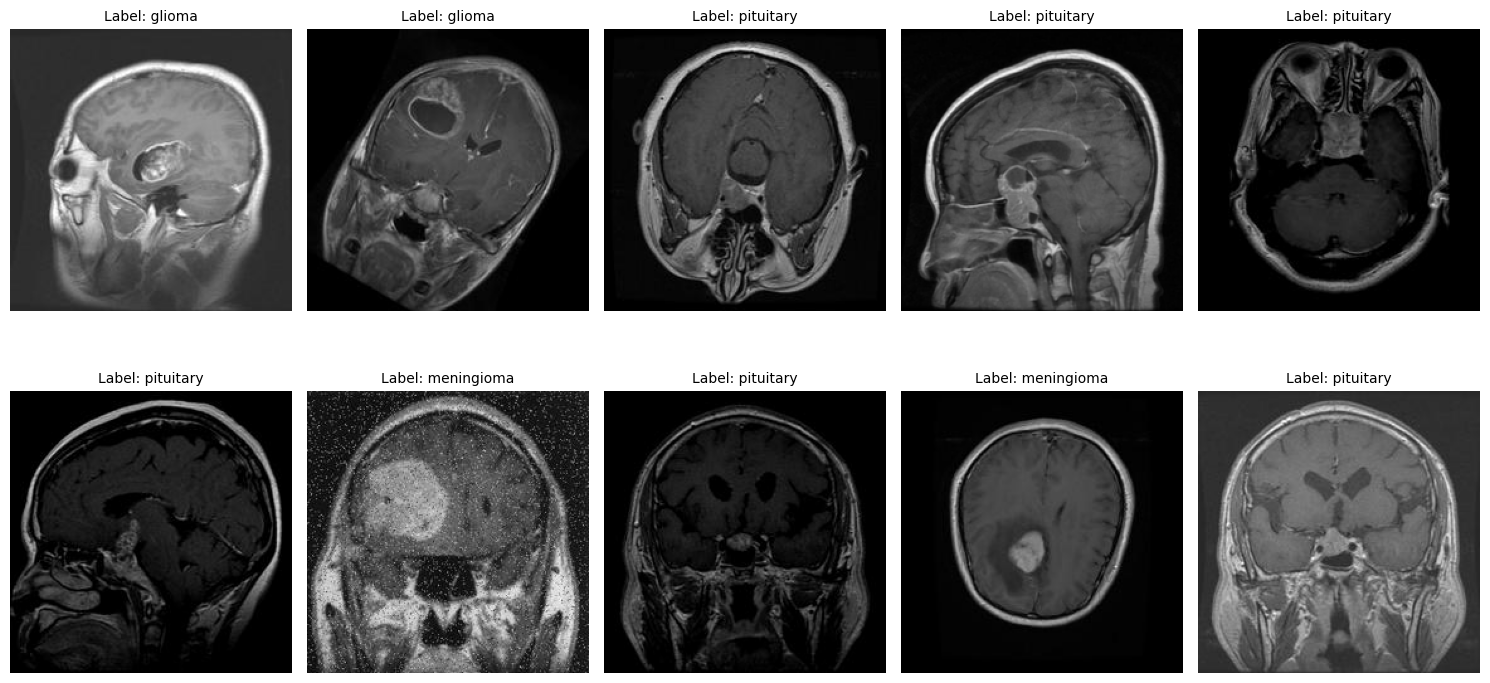

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# ===========================
# قلل الصور لـ 25% (السريع)
# ===========================
reduction = 0.25
train_paths = train_paths[:int(len(train_paths)*reduction)]
train_labels = train_labels[:int(len(train_labels)*reduction)]
test_paths = test_paths[:int(len(test_paths)*reduction)]
test_labels = test_labels[:int(len(test_labels)*reduction)]

print(f"✅ استخدام {len(train_paths)} صورة تدريب و {len(test_paths)} صورة اختبار")


✅ استخدام 4039 صورة تدريب و 1731 صورة اختبار


# Image Preprocessing (Helper Functions)

In [ ]:
# ===========================
# دوال معالجة البيانات (معدلة وسريعة)
# ===========================
IMAGE_SIZE = 128

def encode_label(labels):
    """تحويل أسماء التصنيفات لأرقام"""
    unique_labels = folders
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)


def prepare_data_fast(paths, labels):
    """تحضير البيانات بسرعة - حمّل كل الصور في الذاكرة مرة واحدة"""
    images = []
    encoded_labels = encode_label(labels)

    for idx, path in enumerate(paths):
        try:
            image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
            image = img_to_array(image) / 255.0
            images.append(image)
        except Exception as e:
            print(f"Error loading image {idx}: {e}")
            pass

    return np.array(images), encoded_labels[:len(images)]


print("⏳ Loading training data...")
train_images, train_labels_encoded = prepare_data_fast(train_paths, train_labels)
print(f"✅ Loaded {len(train_images)} training images")

print("⏳ Loading test data...")
test_images, test_labels_encoded = prepare_data_fast(test_paths, test_labels)
print(f"✅ Loaded {len(test_images)} test images")


⏳ Loading training data...
✅ Loaded 4039 training images
⏳ Loading test data...
✅ Loaded 1731 test images


# MODEL:

## WE ARE USING VGG16 FOR TRANSFER LEARNING.

 The model is built on top of VGG16, which is a pre-trained convolutional neural network (CNN) for image classification.

* First, the VGG16 model is loaded with input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet'. The input shape is set to match the size of the images in the dataset, which is 128x128 pixels. The include_top parameter is set to False, which means that the final fully-connected layers of VGG16 that perform the classification will not be included. The weights parameter is set to 'imagenet' which means that the model will be pre-trained with a dataset of 1.4 million images called imagenet

* Next, the for layer in base_model.layers: loop is used to set all layers of the base_model (VGG16) to non-trainable, so that the weights of these layers will not be updated during training.

* Then, the last three layers of the VGG16 model are set to trainable by using base_model.layers[-2].trainable = True,base_model.layers[-3].trainable = True and base_model.layers[-4].trainable = True

* After that, a Sequential model is created and the VGG16 model is added to it with model.add(base_model).

* Next, a Flatten layer is added to the model with model.add(Flatten()) which reshapes the output of the VGG16 model from a 3D tensor to a 1D tensor, so that it can be processed by the next layers of the model.

* Then, a Dropout layer is added with model.add(Dropout(0.3)) which is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.

* After that, a dense layer is added with 128 neurons and relu activation function is added with model.add(Dense(128, activation='relu')).

* Next, another Dropout layer is added with model.add(Dropout(0.2))

* Finally, the output dense layer is added with number of neurons equal to the number of unique labels and 'softmax' activation function is added with model.add(Dense(len(unique_labels), activation='softmax')). The 'softmax' activation function is used to give a probability distribution over the possible classes.




##NEW

In [ ]:
import tensorflow as tf
import os
# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.08),
], name="augmentation")


In [ ]:
# Model architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(folders), activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# عرض ملخص النموذج
model.summary()

# Parameters
# ✅ حطّي ده بدل الأسطر الفات:
BEST_PATH = "/content/drive/MyDrive/model.h5"

ckpt = ModelCheckpoint(
    BEST_PATH,
    monitor="val_sparse_categorical_accuracy",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
    verbose=1
)

early = EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=6,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

batch_size = 64
EPOCHS_STAGE1 = 10

history1 = model.fit(
    train_images, train_labels_encoded,
    validation_data=(test_images, test_labels_encoded),
    epochs=EPOCHS_STAGE1,
    batch_size=batch_size,
    callbacks=[ckpt, early, reduce_lr],
    verbose=1
)

print("✅ Training completed successfully!")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,908 (60.13 MB)

 Trainable params: 8,128,644 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

...

64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step - loss: 0.7556 - sparse_categorical_accuracy: 0.7010 - val_loss: 0.5350 - val_sparse_categorical_accuracy: 0.7828 - learning_rate: 0.0010
Epoch 7/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.4764 - sparse_categorical_accuracy: 0.8206
Epoch 7: val_sparse_categorical_accuracy improved from 0.78278 to 0.80300, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - loss: 0.4757 - sparse_categorical_accuracy: 0.8212 - val_loss: 0.5099 - val_sparse_categorical_accuracy: 0.8030 - learning_rate: 0.0010
Epoch 8/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.3937 - sparse_categorical_accuracy: 0.8575
Epoch 8: val_sparse_categorical_accuracy improved from 0.80300 to 0.82900, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - loss: 0.3927 - sparse_categorical_accuracy: 0.8578 - val_loss: 0.4089 - val_sparse_categorical_accuracy: 0.8290 - learning_rate: 0.0010
Epoch 9/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.2840 - sparse_categorical_accuracy: 0.8938
Epoch 9: val_sparse_categorical_accuracy improved from 0.82900 to 0.87002, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - loss: 0.2836 - sparse_categorical_accuracy: 0.8941 - val_loss: 0.3862 - val_sparse_categorical_accuracy: 0.8700 - learning_rate: 0.0010
Epoch 10/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.4147 - sparse_categorical_accuracy: 0.8533
Epoch 10: val_sparse_categorical_accuracy improved from 0.87002 to 0.88042, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - loss: 0.4119 - sparse_categorical_accuracy: 0.8543 - val_loss: 0.3703 - val_sparse_categorical_accuracy: 0.8804 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.
✅ Training completed successfully!


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

BEST_PATH = "/content/drive/MyDrive/model.h5"

ckpt = ModelCheckpoint(
    BEST_PATH,
    monitor="val_sparse_categorical_accuracy",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
    verbose=1
)

early = EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=6,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ✅ استخدام البيانات المحمّلة بسرعة (مش open_images)
batch_size = 64
EPOCHS_STAGE1 = 10

history1 = model.fit(
    train_images, train_labels_encoded,  # ✅ بدل datagen
    validation_data=(test_images, test_labels_encoded),
    epochs=EPOCHS_STAGE1,
    batch_size=batch_size,
    callbacks=[ckpt, early, reduce_lr],
    verbose=1
)

print("✅ Stage 1 done. Best model saved to:", BEST_PATH)


Epoch 1/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.2237 - sparse_categorical_accuracy: 0.9266
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.87406, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - loss: 0.2231 - sparse_categorical_accuracy: 0.9267 - val_loss: 0.3739 - val_sparse_categorical_accuracy: 0.8741 - learning_rate: 0.0010
Epoch 2/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1805 - sparse_categorical_accuracy: 0.9383
Epoch 2: val_sparse_categorical_accuracy improved from 0.87406 to 0.89370, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - loss: 0.1802 - sparse_categorical_accuracy: 0.9383 - val_loss: 0.3290 - val_sparse_categorical_accuracy: 0.8937 - learning_rate: 0.0010
Epoch 3/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1116 - sparse_categorical_accuracy: 0.9605
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.89370
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - loss: 0.1118 - sparse_categorical_accuracy: 0.9604 - val_loss: 0.4056 - val_sparse_categorical_accuracy: 0.8712 - learning_rate: 0.0010
Epoch 4/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1420 - sparse_categorical_accuracy: 0.9552
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.89370
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - loss: 0.1422 - sparse_categorical_accuracy: 0.9551 - val_loss: 0.4337 - val_sparse_categorical_accuracy: 0.8810 - learning_rate: 0.0010
Epoch 5/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.1038 - sparse_categorical_accuracy: 0.9599
Epoch


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - loss: 0.1037 - sparse_categorical_accuracy: 0.9601 - val_loss: 0.5258 - val_sparse_categorical_accuracy: 0.9024 - learning_rate: 0.0010
Epoch 6/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0542 - sparse_categorical_accuracy: 0.9821
Epoch 6: val_sparse_categorical_accuracy improved from 0.90237 to 0.90526, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - loss: 0.0543 - sparse_categorical_accuracy: 0.9821 - val_loss: 0.4599 - val_sparse_categorical_accuracy: 0.9053 - learning_rate: 5.0000e-04
Epoch 7/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0203 - sparse_categorical_accuracy: 0.9934
Epoch 7: val_sparse_categorical_accuracy did not improve from 0.90526
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - loss: 0.0204 - sparse_categorical_accuracy: 0.9933 - val_loss: 0.4968 - val_sparse_categorical_accuracy: 0.9001 - learning_rate: 5.0000e-04
Epoch 8/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0224 - sparse_categorical_accuracy: 0.9928
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.90526

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - loss: 0.0225 - sparse_categorical_accuracy: 0.9928 - val_loss: 0.4664 - val_sparse_categorical_accuracy: 0.8954 - learning_rate: 5.0000e-04
Epoch 9/10
63/64 ━━━━

64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - loss: 0.0187 - sparse_categorical_accuracy: 0.9946 - val_loss: 0.6142 - val_sparse_categorical_accuracy: 0.9122 - learning_rate: 2.5000e-04
Epoch 10/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0055 - sparse_categorical_accuracy: 0.9985
Epoch 10: val_sparse_categorical_accuracy improved from 0.91219 to 0.91450, saving model to /content/drive/MyDrive/model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - loss: 0.0056 - sparse_categorical_accuracy: 0.9985 - val_loss: 0.7121 - val_sparse_categorical_accuracy: 0.9145 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 10.
✅ Stage 1 done. Best model saved to: /content/drive/MyDrive/model.h5


# Train and Val Plots

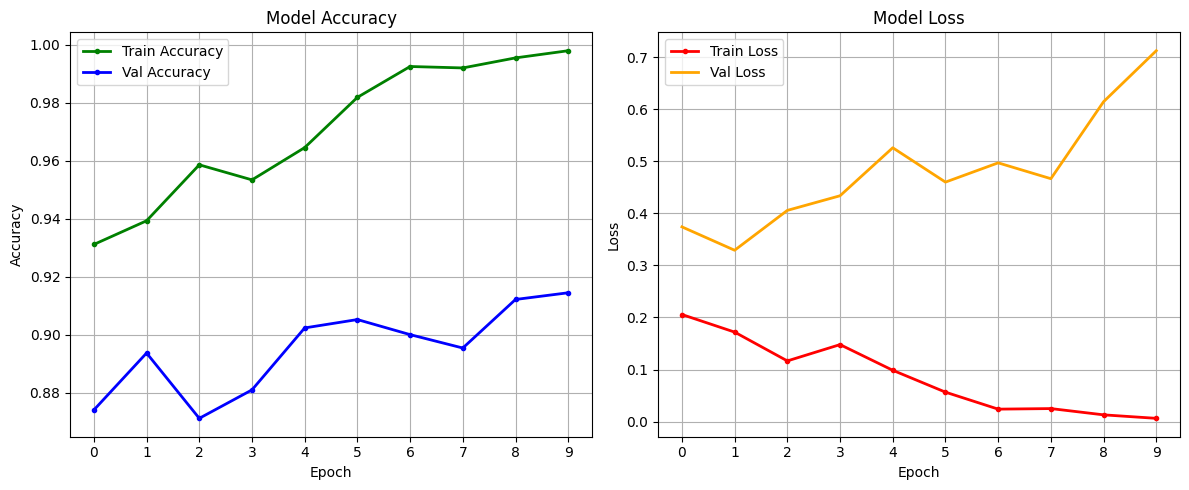

In [ ]:
plt.figure(figsize=(12, 5))

# رسم Accuracy
plt.subplot(1, 2, 1)
plt.grid(True)
plt.plot(history1.history['sparse_categorical_accuracy'], '.g-', linewidth=2, label='Train Accuracy')
plt.plot(history1.history['val_sparse_categorical_accuracy'], '.b-', linewidth=2, label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.xticks([x for x in range(len(history1.history['sparse_categorical_accuracy']))])

# رسم Loss
plt.subplot(1, 2, 2)
plt.grid(True)
plt.plot(history1.history['loss'], '.r-', linewidth=2, label='Train Loss')
plt.plot(history1.history['val_loss'], '-', color='orange', linewidth=2, label='Val Loss')  # ✅ صحيح
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.xticks([x for x in range(len(history1.history['loss']))])

plt.tight_layout()
plt.show()


# Model Classification Report

In [ ]:
# 2. Get predictions on test data
test_predictions = model.predict(test_images)
print("✅ Predictions completed!")


55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step
✅ Predictions completed!



Confusion Matrix:
[[496   4  14   0]
 [  4 533  40   0]
 [ 14  53 521   3]
 [  0  10   6  33]]


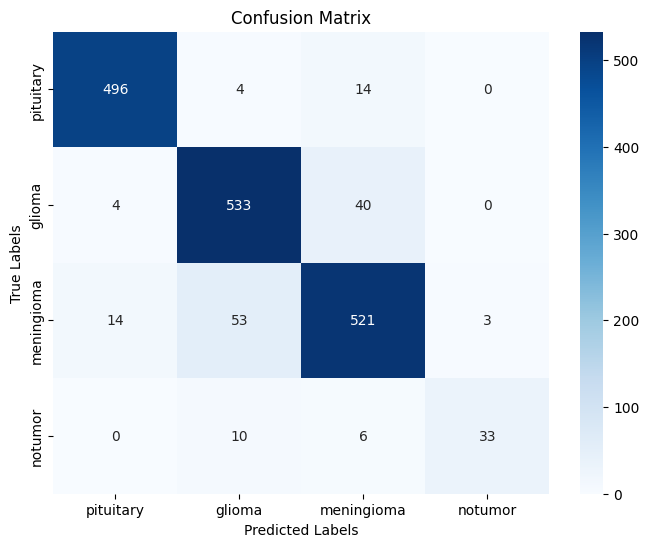

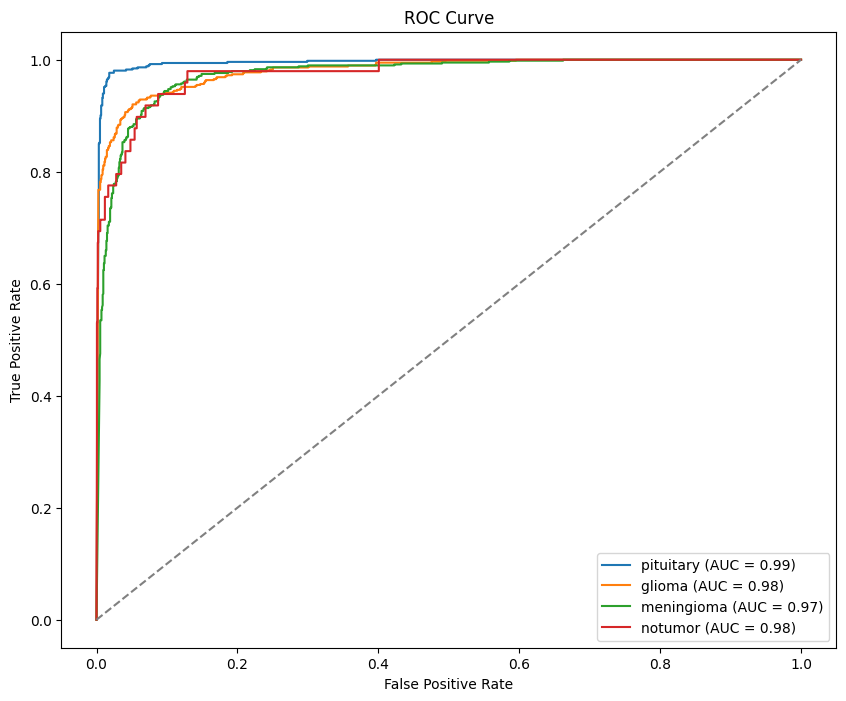

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=folders, yticklabels=folders)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# 4. ROC Curve (Multi-class)
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(folders)))
test_predictions_bin = test_predictions

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(folders)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(folders)):
    plt.plot(fpr[i], tpr[i], label=f'{folders[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


# Model Confusion Plot

Confusion Matrix:
[[496   4  14   0]
 [  4 533  40   0]
 [ 14  53 521   3]
 [  0  10   6  33]]


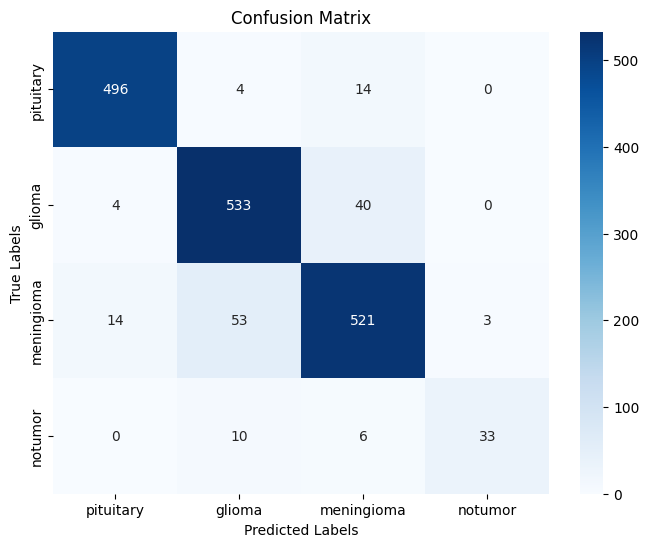

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=folders, yticklabels=folders)  # ✅ استخدمي folders
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Roc Curve Plot


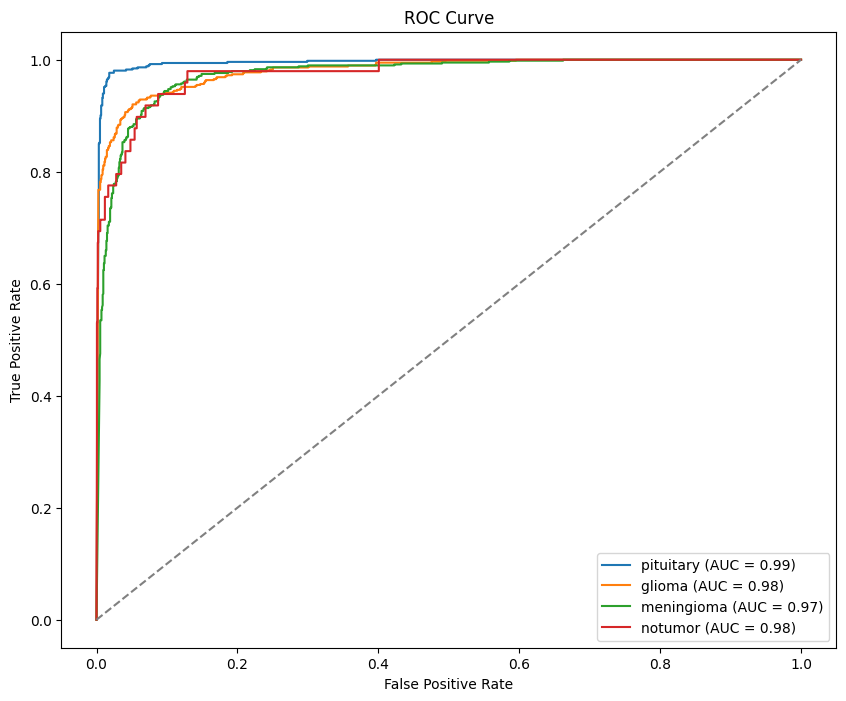

In [ ]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(folders)))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(folders)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(folders)):
    plt.plot(fpr[i], tpr[i], label=f'{folders[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


# Save & Load Model

In [ ]:
# Save to Google Drive
model.save('/content/drive/MyDrive/model.h5')
print("✅ Model saved to Google Drive!")


✅ Model saved to Google Drive!


In [ ]:
from tensorflow.keras.models import load_model

# Load the trained model from Google Drive
model = load_model('/content/drive/MyDrive/model.h5')
print("✅ Model loaded from Google Drive successfully!")


✅ Model loaded from Google Drive successfully!


# MRI Tumor Detection System

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels - نفس الترتيب اللي استخدمنا في folders
class_labels = ['pituitary', 'glioma', 'meningioma', 'notumor']  # ✅ الترتيب الصحيح

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


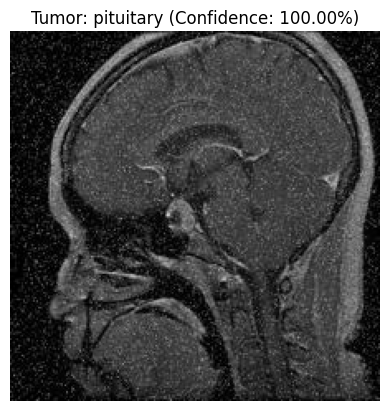

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/MRI NEW/pituitary/P_108_SP_.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

In [ ]:

# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-noTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0006.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Training/glioma/Tr-glTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)